In [1]:
%cd ..

c:\Users\user\OneDrive\Desktop\170A-CHOC


In [2]:
from data.data_partitioner import DataPartitioner

In [3]:
data = DataPartitioner(data_dir='data')
data.load_datasets()

In [4]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt

In [5]:
df = data.choc
df_test = data.choc_svi[df.columns.tolist()]
df_eval = data.choc_svi_coi[df.columns.tolist()]

In [6]:
# Convert categorical feature columns into dummy variables
df_enc = pd.get_dummies(df)
df_test_enc = pd.get_dummies(df_test)
df_eval_enc = pd.get_dummies(df_eval)

In [8]:
# Assuming 'df' is your DataFrame and 'target' is the column you want to predict
X_train = df_enc.drop(['no_show_Yes','no_show_No', 'NOSHOWS_365'], axis=1)
y_train = df_enc['no_show_Yes']
X_test = df_test_enc.drop(['no_show_Yes','no_show_No', 'NOSHOWS_365'], axis=1)
y_test = df_test_enc['no_show_Yes']
X_eval =  df_eval_enc.drop(['no_show_Yes','no_show_No', 'NOSHOWS_365'], axis=1)
y_eval = df_eval_enc['no_show_Yes']

In [9]:
# Initialize the classifier
clf = DecisionTreeClassifier(
    max_depth=2,           # The tree grows until all leaves are pure
    min_samples_split=200,      # The minimum samples required to split a node
    min_samples_leaf=1,       # The minimum samples allowed in a leaf
    max_leaf_nodes=None,       # Unlimited number of leaf nodes
    criterion='gini',
    random_state=42)

# Train the model
clf.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,2
,min_samples_split,200
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


              precision    recall  f1-score   support

       False       0.88      1.00      0.94     27089
        True       0.89      0.07      0.13      3888

    accuracy                           0.88     30977
   macro avg       0.89      0.53      0.53     30977
weighted avg       0.88      0.88      0.84     30977



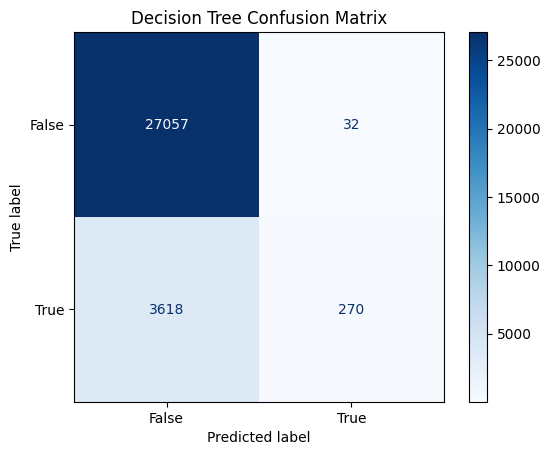

In [10]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
y_pred=clf.predict(X_train)
print(classification_report(y_train, y_pred))
# 2. Compute the confusion matrix
cm = confusion_matrix(y_train, y_pred)

# 3. Plot it
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Decision Tree Confusion Matrix")
plt.show()

              precision    recall  f1-score   support

       False       0.90      1.00      0.95     60672
        True       0.87      0.08      0.15      7519

    accuracy                           0.90     68191
   macro avg       0.89      0.54      0.55     68191
weighted avg       0.90      0.90      0.86     68191



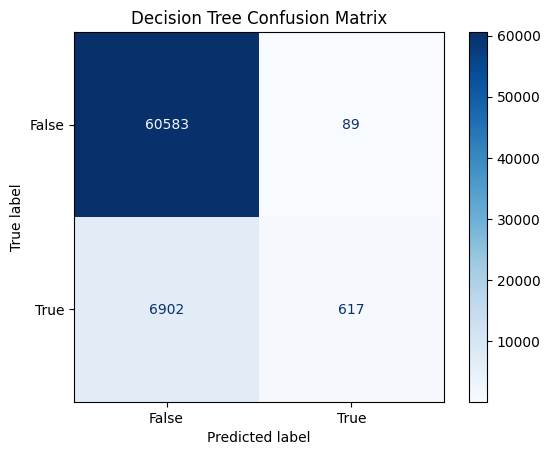

In [11]:
y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))
# 2. Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# 3. Plot it
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Decision Tree Confusion Matrix")
plt.show()

              precision    recall  f1-score   support

       False       0.88      1.00      0.94    401736
        True       0.86      0.04      0.08     57649

    accuracy                           0.88    459385
   macro avg       0.87      0.52      0.51    459385
weighted avg       0.88      0.88      0.83    459385



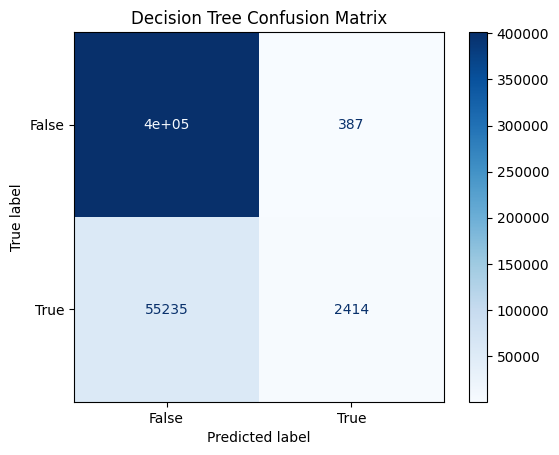

In [12]:
y_pred=clf.predict(X_eval)
print(classification_report(y_eval, y_pred))
# 2. Compute the confusion matrix
cm = confusion_matrix(y_eval, y_pred)

# 3. Plot it
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Decision Tree Confusion Matrix")
plt.show()

In [13]:
from sklearn.tree import export_text

# show_weights=True adds the counts for each class
rules = export_text(clf, feature_names=list(X_train.columns), show_weights=True)
print(rules)

|--- INSURANCE_TYPE_Other/Unknown <= 0.50
|   |--- INSURANCE_TYPE_Commercial <= 0.50
|   |   |--- weights: [11038.00, 2047.00] class: False
|   |--- INSURANCE_TYPE_Commercial >  0.50
|   |   |--- weights: [15914.00, 1483.00] class: False
|--- INSURANCE_TYPE_Other/Unknown >  0.50
|   |--- PRIMARY_CARE_365 <= 0.50
|   |   |--- weights: [105.00, 88.00] class: False
|   |--- PRIMARY_CARE_365 >  0.50
|   |   |--- weights: [32.00, 270.00] class: True



In [15]:
# Assuming your column name is 'noshow' and values are 'Yes'/'No'
summary_df = df.pivot_table(
    index=['age', 
           'GENDER', 
           'RACE', 
           'ETHNICITY',
           'MOBILITY_ABILITY_DX_IND',
           'MENTAL_HEALTH_DX_IND',
           'INSURANCE_TYPE',
           ], 
    columns='no_show', 
    aggfunc='size', 
    fill_value=0
).reset_index()

# Rename columns for clarity
summary_df.columns.name = None
summary_df = summary_df.rename(columns={'No': 'indv_noshow_no', 'Yes': 'indv_noshow_yes'})

In [16]:
summary_df.shape

(2431, 9)

In [18]:
# Assuming 'clf' is your trained DecisionTreeClassifier
# and 'X' is the feature set used for that tree
df['leaf_id'] = clf.apply(X_train)

In [19]:
# 1. Total count per leaf group
leaf_counts = df.groupby('leaf_id').size().rename('total_group_count')

# 2. Breakdown of shows vs no-shows per leaf
# Assuming 'noshow' column has values 'Yes' and 'No'
leaf_stats = df.groupby(['leaf_id', 'no_show']).size().unstack(fill_value=0)

# Rename columns for clarity
leaf_stats = leaf_stats.rename(columns={'No': 'group_show_count', 'Yes': 'group_noshow_count'})

In [20]:
# Join the total counts
df = df.merge(leaf_counts, on='leaf_id', how='left')

# Join the show/no-show breakdown
df = df.merge(leaf_stats, on='leaf_id', how='left')

# Optional: Calculate the probability/rate for that group
df['group_noshow_rate'] = df['group_noshow_count'] / df['total_group_count']

In [22]:
df_final = df.merge(summary_df, on= ['age', 
           'GENDER', 
           'RACE', 
           'ETHNICITY',
           'MOBILITY_ABILITY_DX_IND',
           'MENTAL_HEALTH_DX_IND',
           'INSURANCE_TYPE'
           ], how='left')

In [24]:
nndf = df_eval

In [25]:
nndf = nndf.merge(summary_df, on= ['age', 
           'GENDER', 
           'RACE', 
           'ETHNICITY',
           'MOBILITY_ABILITY_DX_IND',
           'MENTAL_HEALTH_DX_IND',
           'INSURANCE_TYPE'
           ], how='left')

In [31]:
nndf['leaf_id'] = clf.apply(X_eval)

In [ ]:
# Join the show/no-show breakdown
nndf = nndf.merge(leaf_stats, on='leaf_id', how='left')

In [36]:
nndf = nndf.fillna(0)

In [40]:
ndf = nndf[['no_show','indv_noshow_no','indv_noshow_yes', 'group_show_count','group_noshow_count']]

In [42]:
ndf['no_show'] = (ndf['no_show'] =='Yes').astype(int)

C:\Users\user\AppData\Local\Temp\ipykernel_18080\3839501371.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ndf['no_show'] = (ndf['no_show'] =='Yes').astype(int)


In [83]:
import torch
import numpy as np
import random
import os
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Beta
def set_seed(seed=42):
    # 1. Basic Python and NumPy seeds
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    
    # 2. PyTorch seeds
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed) # for multi-GPU
    
    # 3. Force CuDNN to be deterministic (Note: this can slightly slow down training)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)
# 1. Prepare Inputs (Group counts and Individual counts)
# We often log-transform or scale counts so the NN handles them better
X = torch.tensor(ndf[['group_noshow_count', 'group_show_count', 
                    'indv_noshow_yes', 'indv_noshow_no']].values, dtype=torch.float32)

# 2. Prepare Target (1 for No-Show, 0 for Show)
# Ensure your 'no_show' column is 1/0
y = torch.tensor(ndf['no_show'].values, dtype=torch.float32).view(-1, 1)

In [127]:
class BayesianWeightNet(nn.Module):
    def __init__(self):
        super(BayesianWeightNet, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(4, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 2), # Two weights: w_group and w_individual
        )

    def forward(self, x_raw):
        # Rates (Probabilities between 0 and 1)
        g_rate = x_raw[:, 0:1] / (x_raw[:, 0] + x_raw[:, 1] + 1e-6).view(-1, 1)
        i_rate = x_raw[:, 2:3] / (x_raw[:, 2] + x_raw[:, 3] + 1e-6).view(-1, 1)
        
        # NN Outputs
        phi = torch.sigmoid(self.net(torch.log1p(x_raw)))
        
        # DIFFERENTIAL SCALING:
        # Cap Group influence at 5 'effective appointments'
        # Cap Individual influence at 50 'effective appointments'
        w_g = phi[:, 0:1] * 15.0  
        w_i = phi[:, 1:2] * 50.0 
        
        # Now, if a person has 10 real appointments, 
        # they can easily 'outvote' the group's prior.
        alpha = (w_g * g_rate) + (w_i * i_rate) + 1.0
        beta_param = (w_g * (1-g_rate)) + (w_i * (1-i_rate)) + 1.0
        
        # Reparameterized Sampling
        dist = Beta(alpha, beta_param)
        p_hat = dist.rsample() 
        
        return p_hat, alpha, beta_param, w_g, w_i

In [128]:
model = BayesianWeightNet()
optimizer = optim.Adam(model.parameters(), lr=0.007)
criterion = nn.BCELoss()

for epoch in range(61):
    model.train()
    optimizer.zero_grad()
    
    # Catch the weights w_g (Group) and w_i (Individual)
    p_hat, a, b, wg, wi = model(X)
    
    loss = criterion(p_hat, y)
    loss.backward()
    optimizer.step()
    
    if epoch % 10 == 0:
        # We use .detach() so we don't accidentally keep the computation graph in memory
        avg_group_w = wg.mean().item()
        avg_indiv_w = wi.mean().item()
        max_group_w = wg.max().item()
        max_indiv_w = wi.max().item()

        print(f"Epoch {epoch:3d} | Loss: {loss.item():.4f}")
        print(f"   > Weights [Avg] - Group: {avg_group_w:.4f}, Indiv: {avg_indiv_w:.4f}")
        print(f"   > Weights [Max] - Group: {max_group_w:.4f}, Indiv: {max_indiv_w:.4f}")
        print(f"   > Posteriors    - Avg Alpha: {a.mean().item():.2f}, Avg Beta: {b.mean().item():.2f}")
        print("-" * 60)

Epoch   0 | Loss: 0.4061
   > Weights [Avg] - Group: 7.6409, Indiv: 41.6804
   > Weights [Max] - Group: 8.0267, Indiv: 43.0428
   > Posteriors    - Avg Alpha: 6.97, Avg Beta: 44.35
------------------------------------------------------------
Epoch  10 | Loss: 0.3862
   > Weights [Avg] - Group: 14.9287, Indiv: 9.0597
   > Weights [Max] - Group: 14.9715, Indiv: 15.6908
   > Posteriors    - Avg Alpha: 4.02, Avg Beta: 21.97
------------------------------------------------------------
Epoch  20 | Loss: 0.3828
   > Weights [Avg] - Group: 14.9924, Indiv: 16.1633
   > Weights [Max] - Group: 14.9971, Indiv: 26.7073
   > Posteriors    - Avg Alpha: 4.94, Avg Beta: 28.21
------------------------------------------------------------
Epoch  30 | Loss: 0.3797
   > Weights [Avg] - Group: 14.9968, Indiv: 26.4466
   > Weights [Max] - Group: 14.9986, Indiv: 45.2353
   > Posteriors    - Avg Alpha: 6.28, Avg Beta: 37.16
------------------------------------------------------------
Epoch  40 | Loss: 0.3792
  

In [129]:
model.eval()
with torch.no_grad():
    _, final_alphas, final_betas, _,_ = model(X)

# Add them back to your dataframe for analysis
ndf['posterior_alpha'] = final_alphas.numpy()
ndf['posterior_beta'] = final_betas.numpy()
ndf['predicted_risk'] = ndf['posterior_alpha'] / (ndf['posterior_alpha'] + ndf['posterior_beta'])

C:\Users\user\AppData\Local\Temp\ipykernel_18080\3089194496.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ndf['posterior_alpha'] = final_alphas.numpy()
C:\Users\user\AppData\Local\Temp\ipykernel_18080\3089194496.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ndf['posterior_beta'] = final_betas.numpy()
C:\Users\user\AppData\Local\Temp\ipykernel_18080\3089194496.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] 

In [131]:
# Add them back to your dataframe for analysis
nndf['posterior_alpha'] = ndf['posterior_alpha']
nndf['posterior_beta'] = ndf['posterior_beta']
nndf['predicted_risk'] = ndf['predicted_risk']

In [133]:
# Usually use .pth or .pt extension
torch.save(model.state_dict(), 'decision_tree_classifier/bayesian_weight_net.pth')

In [134]:
# 1. Re-instantiate the model class
model = BayesianWeightNet()

# 2. Load the weights
model.load_state_dict(torch.load('decision_tree_classifier/bayesian_weight_net.pth'))

# 3. ALWAYS set to eval mode if you're done training
model.eval()

BayesianWeightNet(
  (net): Sequential(
    (0): Linear(in_features=4, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=2, bias=True)
  )
)

In [135]:
qq = ndf.groupby('predicted_risk').mean()['no_show'].reset_index()

In [136]:
qq

,predicted_risk,no_show
0,0.042122,0.064103
1,0.044650,0.057915
2,0.045113,0.097633
3,0.045767,0.057998
4,0.047527,0.078767
...,...,...
568,0.857758,0.901288
569,0.859544,0.886364
570,0.860928,0.886076
571,0.862159,0.666667


C:\Users\user\AppData\Local\Temp\ipykernel_18080\2817159182.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


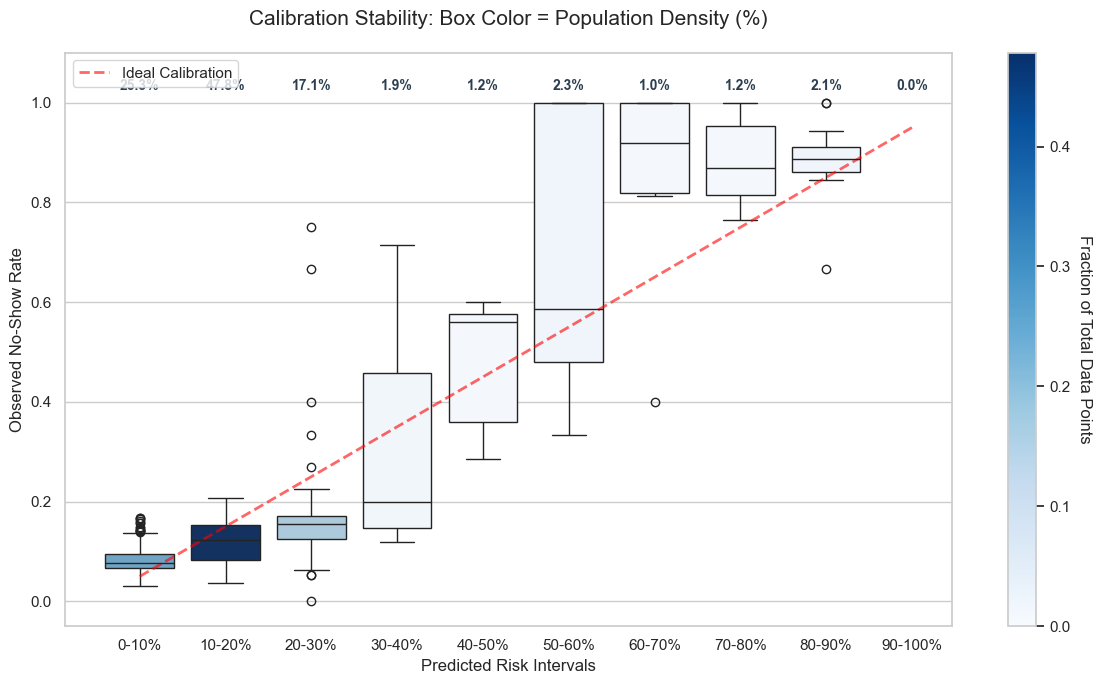

In [139]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.cm as cm

# 1. Create 10% wide bins
bins = np.linspace(0, 1, 11)
labels = [f"{int(bins[i]*100)}-{int(bins[i+1]*100)}%" for i in range(len(bins)-1)]
qq['risk_bin'] = pd.cut(qq['predicted_risk'], bins=bins, labels=labels, include_lowest=True)

# 2. Calculate fractions (counts divided by total)
bin_counts = qq['risk_bin'].value_counts().sort_index()
bin_fractions = bin_counts / bin_counts.sum()  # Normalizing to get fractions (0 to 1)

# 3. Create a color palette based on fractions
# We use 'mako' or 'Blues' for a clean density look
norm = plt.Normalize(bin_fractions.min(), bin_fractions.max())
colors = [cm.Blues(norm(value)) for value in bin_fractions.values]

# 4. Set the visual style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 7))

# 5. Create the Box Plot with the fraction-based palette
ax = sns.boxplot(
    data=qq, 
    x='risk_bin', 
    y='no_show', 
    palette=colors,
    showfliers=True
)

# 6. Add the Identity Line (The Target)
plt.plot(range(10), np.arange(0.05, 1.0, 0.1), 
         color='red', linestyle='--', linewidth=2, alpha=0.6, label='Ideal Calibration')

# 7. Add a Colorbar mapped to percentage
sm = plt.cm.ScalarMappable(cmap=cm.Blues, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label('Fraction of Total Data Points', rotation=270, labelpad=15)

# 8. Overlay the % text on each box for clarity
for i, fraction in enumerate(bin_fractions.values):
    plt.text(i, 1.02, f'{fraction:.1%}', ha='center', va='bottom', fontsize=10, fontweight='bold', color='#2c3e50')

# 9. Clean up Labels
plt.title('Calibration Stability: Box Color = Population Density (%)', fontsize=15, pad=20)
plt.xlabel('Predicted Risk Intervals', fontsize=12)
plt.ylabel('Observed No-Show Rate', fontsize=12)
plt.ylim(-0.05, 1.1)
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_18080\840115042.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(


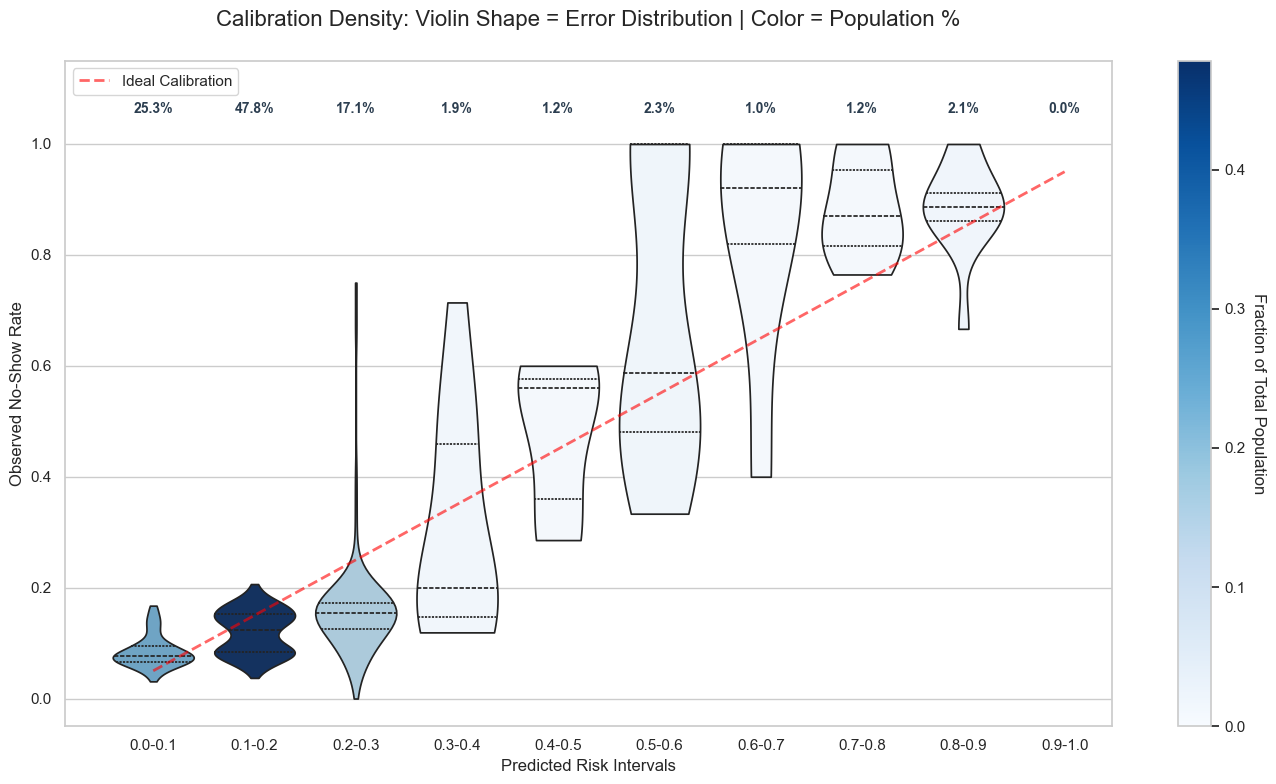

In [142]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.cm as cm

# 1. Create 10% wide bins
bins = np.linspace(0, 1, 11)
labels = [f"{bins[i]:.1f}-{bins[i+1]:.1f}" for i in range(len(bins)-1)]
qq['risk_bin'] = pd.cut(qq['predicted_risk'], bins=bins, labels=labels, include_lowest=True)

# 2. Calculate fractions 
bin_counts = qq['risk_bin'].value_counts().sort_index()
bin_fractions = bin_counts / bin_counts.sum()

# 3. Create a color palette 
norm = plt.Normalize(bin_fractions.min(), bin_fractions.max())
colors = [cm.Blues(norm(value)) for value in bin_fractions.values]

# 4. Visual style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 8))

# 5. THE VIOLIN PLOT
# inner="quartile" shows the internal stats
# cut=0 prevents the violin from extending beyond real data limits
ax = sns.violinplot(
    data=qq, 
    x='risk_bin', 
    y='no_show', 
    palette=colors,
    inner='quartile', 
    cut=0
)

# 6. Add the Identity Line
plt.plot(range(10), np.arange(0.05, 1.0, 0.1), 
         color='red', linestyle='--', linewidth=2, alpha=0.6, label='Ideal Calibration')

# 7. Add a Colorbar
sm = plt.cm.ScalarMappable(cmap=cm.Blues, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label('Fraction of Total Population', rotation=270, labelpad=15)

# 8. Overlay % text
for i, fraction in enumerate(bin_fractions.values):
    plt.text(i, 1.05, f'{fraction:.1%}', ha='center', va='bottom', 
             fontsize=10, fontweight='bold', color='#2c3e50')

# 9. Clean up
plt.title('Calibration Density: Violin Shape = Error Distribution | Color = Population %', fontsize=16, pad=25)
plt.xlabel('Predicted Risk Intervals', fontsize=12)
plt.ylabel('Observed No-Show Rate', fontsize=12)
plt.ylim(-0.05, 1.15) 
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()

Brier Score: 0.1064
ROC-AUC: 0.5991
Log-Loss: 0.3678


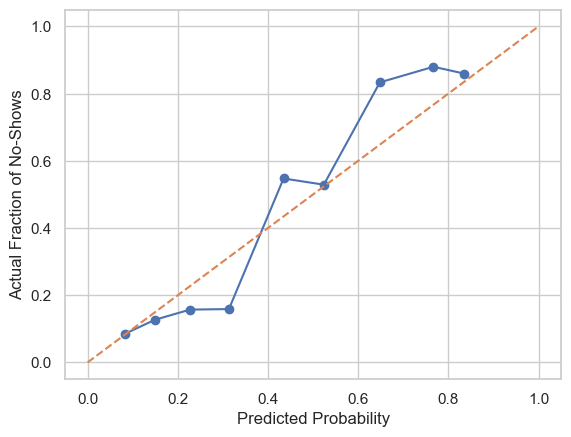

In [143]:
from sklearn.metrics import brier_score_loss, roc_auc_score, log_loss
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt
y_true = ndf['no_show']
y_prob = ndf['predicted_risk']
# Metrics
print(f"Brier Score: {brier_score_loss(y_true, y_prob):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_true, y_prob):.4f}")
print(f"Log-Loss: {log_loss(y_true, y_prob):.4f}")

# Calibration Plot
prob_true, prob_pred = calibration_curve(y_true, y_prob, n_bins=10)
plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("Predicted Probability")
plt.ylabel("Actual Fraction of No-Shows")
plt.show()